
[![Electronic Profile](https://img.shields.io/badge/Electronic%20Profile-engineer--e-181717?logo=github)](https://github.com/engineer-e/) 
[![Work Profile](https://img.shields.io/badge/Work%20Profile-engineer--work-181717?logo=github)](https://github.com/engineer-work/) 
[![Instagram](https://img.shields.io/badge/Instagram-gobalkrishnan.engineer-E4405F?logo=instagram&logoColor=white)](https://www.instagram.com/gobalkrishnan.engineer/)

# 5. Adding a Sphere

## 5.2 Creating Our First Raytraced Image



In [11]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

from util.ray import Ray
from util.vec3 import Vec3
from util.color import write_color
from util.vec3 import unit_vector
from util.vec3 import dot
from tqdm import tqdm



In [12]:
def hit_sphere( center,  radius,  ray) :
    oc = center - ray.origin();
    a = dot(ray.direction(), ray.direction());
    b = -2.0 * dot(ray.direction(), oc);
    c = dot(oc, oc) - radius*radius;
    discriminant = b*b - 4*a*c;
    return (discriminant >= 0);
    
    

In [13]:

# -----------------------------
# Sky color function
# -----------------------------
def ray_color(ray):

    if (hit_sphere(Vec3(0,0,-1), 0.5, ray)):
        return Vec3(1, 0, 0);

    unit_direction = unit_vector(ray.direction())

    # scale y from [-1,1] to [0,1]
    a = 0.5 * (unit_direction.y + 1.0)

    white = Vec3(1.0, 1.0, 1.0)
    blue = Vec3(0.5, 0.7, 1.0)

    # lerp
    return white * (1.0 - a) + blue * a

In [18]:
# -----------------------------
# IMAGE / CAMERA SETUP
# -----------------------------

# Aspect ratio of the final image (width : height)
# Example: 16:9 widescreen
aspect_ratio = 16.0 / 9.0

# Total number of horizontal pixels
image_width = 1980

# Compute vertical pixels based on aspect ratio
image_height = int(image_width / aspect_ratio)


# -----------------------------
# CAMERA / VIEWPORT CONFIGURATION
# -----------------------------

# Distance between camera center and viewport
# This acts like "eye to retina" distance (focal length)
focal_length = 1

# Physical height of the viewport in world space
viewport_height = 2.0

# Physical width of viewport, scaled by aspect ratio
viewport_width = viewport_height * (image_width / image_height)

# Camera position (origin point)
# Think of this as the eye location
camera_center = Vec3(0, 0, 0)


# -----------------------------
# VIEWPORT AXIS VECTORS
# -----------------------------

# Horizontal vector of viewport
# Goes left → right
viewport_u = Vec3(viewport_width, 0, 0)

# Vertical vector of viewport
# Negative y means top → down
viewport_v = Vec3(0, -viewport_height, 0)


# -----------------------------
# PIXEL SIZE IN WORLD SPACE
# -----------------------------

# Width of one pixel in viewport space
pixel_delta_u = viewport_u / image_width

# Height of one pixel in viewport space
pixel_delta_v = viewport_v / image_height


# -----------------------------
# VIEWPORT POSITIONING
# -----------------------------

# Find the top-left corner of the viewport
#
# Steps:
# 1. Move forward along z-axis by focal length
# 2. Shift left by half viewport width
# 3. Shift up by half viewport height
viewport_upper_left = (
    camera_center
    - Vec3(0, 0, focal_length)
    - viewport_u / 2
    - viewport_v / 2
)


# -----------------------------
# FIRST PIXEL CENTER
# -----------------------------

# Move half pixel right and half pixel down
# so rays pass through the center of pixel (0,0)
pixel00_loc = viewport_upper_left + (
    (pixel_delta_u + pixel_delta_v) * 0.5
)


# -----------------------------
# SAVE IMAGE FILE (PPM FORMAT)
# -----------------------------

# Open output file in write mode
with open("output.ppm", "w") as f:

    # PPM Header:
    # P3 = plain text RGB format
    # width height
    # max color value
    f.write(f"P3\n{image_width} {image_height}\n255\n")


    # -----------------------------
    # LOOP THROUGH EACH PIXEL
    # -----------------------------
    
    # j = row (top to bottom)
    for j in tqdm(range(image_height), desc="Rendering"):


        # i = column (left to right)
        for i in range(image_width):


            # -----------------------------
            # COMPUTE CURRENT PIXEL POSITION
            # -----------------------------
            
            # Start from first pixel and move:
            # i steps horizontally
            # j steps vertically
            pixel_center = (
                pixel00_loc
                + pixel_delta_u * i
                + pixel_delta_v * j
            )


            # -----------------------------
            # CREATE RAY
            # -----------------------------
            
            # Ray direction = pixel position - camera position
            # This shoots a ray from eye → pixel
            ray_direction = pixel_center - camera_center

            # Create ray object
            r = Ray(camera_center, ray_direction)


            # -----------------------------
            # GET COLOR FOR THIS RAY
            # -----------------------------
            
            # Trace ray into scene
            # ray_color() decides what color it sees
            pixel_color = ray_color(r)


            # -----------------------------
            # CONVERT FLOAT COLORS TO 0–255
            # -----------------------------
            
            ir = int(255.999 * pixel_color.x)  # Red
            ig = int(255.999 * pixel_color.y)  # Green
            ib = int(255.999 * pixel_color.z)  # Blue


            # -----------------------------
            # WRITE PIXEL TO IMAGE
            # -----------------------------
            
            f.write(f"{ir} {ig} {ib}\n")


# Rendering complete
print("Done!")

Rendering: 100%|██████████| 1113/1113 [00:20<00:00, 53.46it/s]

Done!


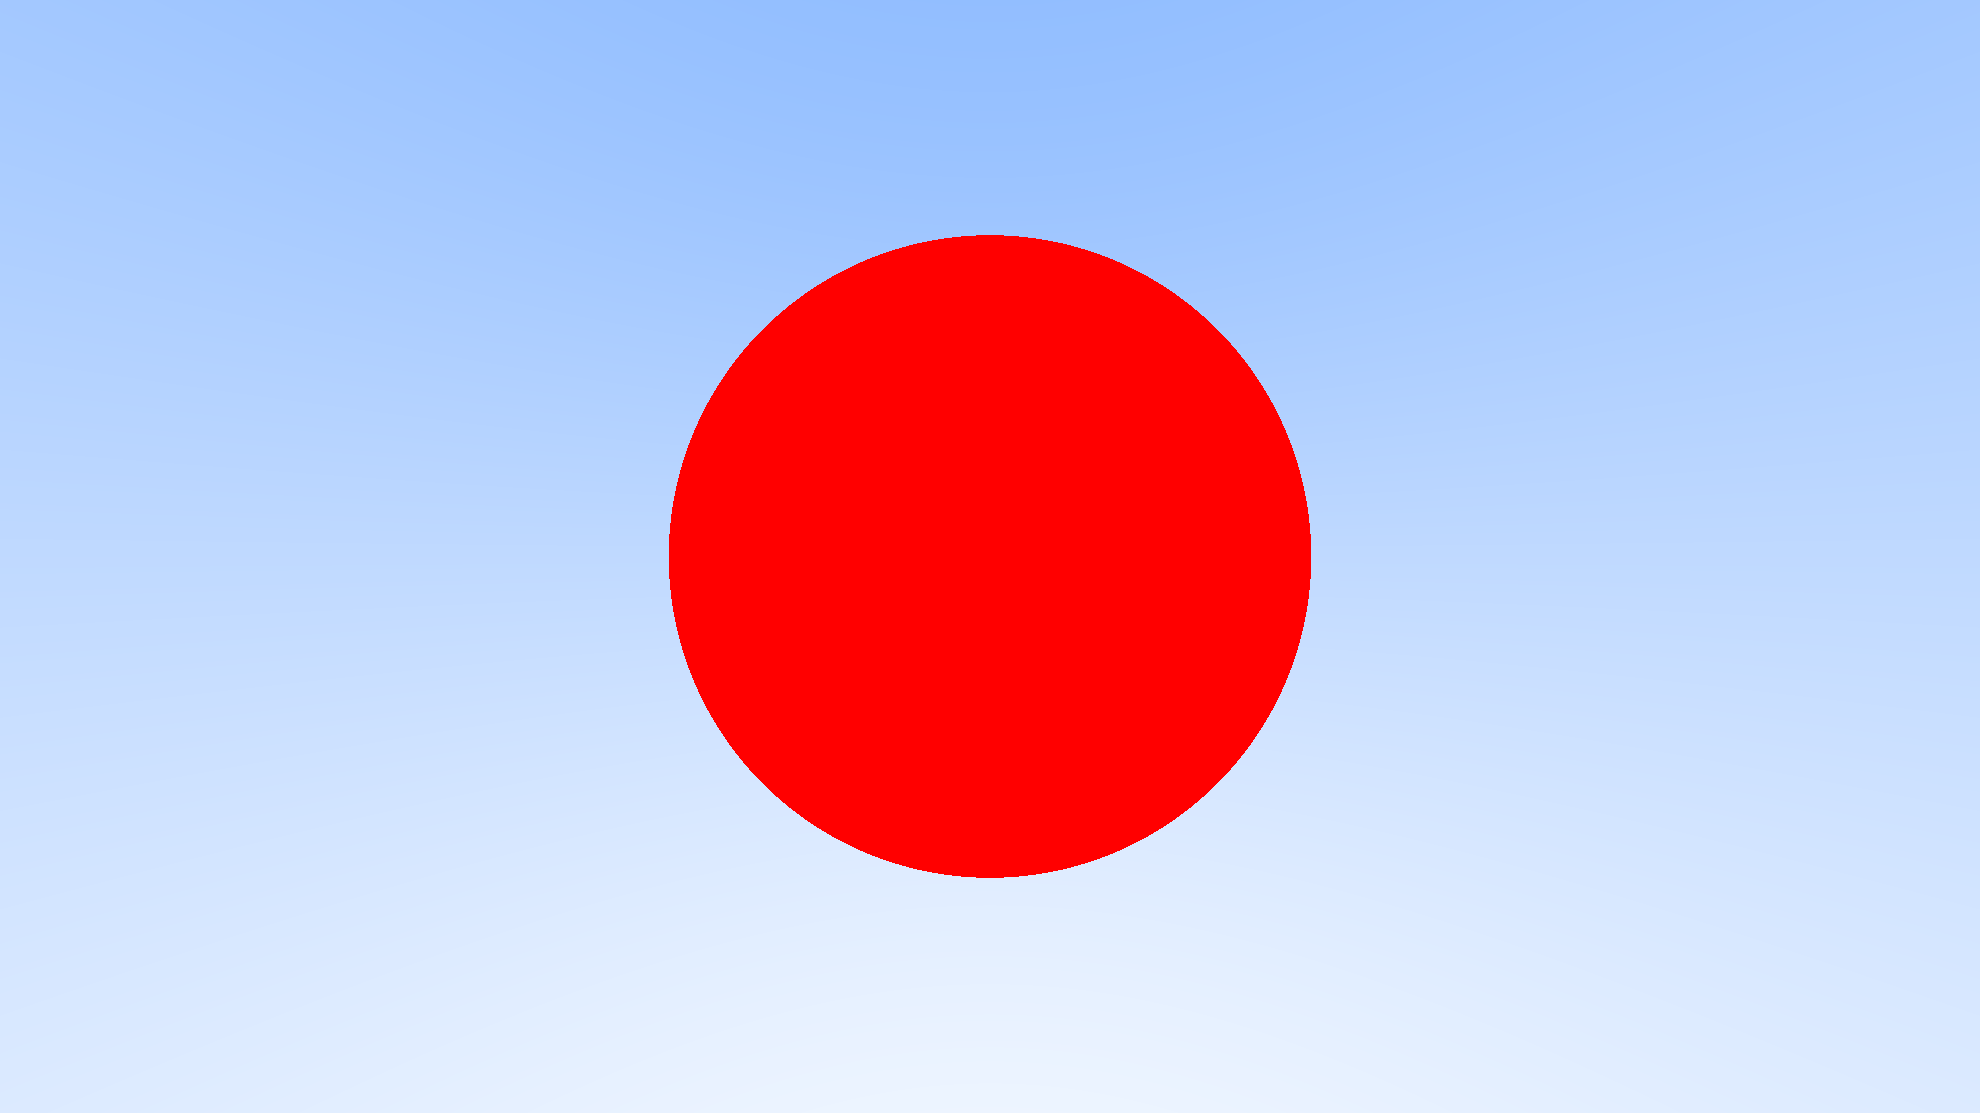

In [19]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("output.ppm")
a